# 04 — Evaluation and post-processing

Two goals:
1. **Evaluate** whether the cosine-similarity cell-type assignments are biologically plausible,
   using known marker genes as ground truth.
2. **Post-process** low-confidence assignments — cells whose best cosine similarity score
   falls below a threshold are flagged and optionally re-segmented at a different diameter.

**Inputs**
- `data/cell_expression_crop.csv` — cells × genes count matrix
- `data/prototypes_normalized.csv` — cell-type prototypes
- `data/cell_type_predictions.csv` — assignments from notebook 03
- `data/cosine_similarity_matrix.csv` — full similarity matrix
- `data/masks_center.npy` — Cellpose segmentation mask
- `data/morphology_focus_0000.ome.tif` — original image (for re-segmentation)

**Outputs**
- `data/cell_type_predictions_refined.csv` — predictions with low-confidence cells flagged
- `outputs/marker_gene_heatmap.png` — marker gene expression per predicted cell type
- `outputs/confidence_map.png` — spatial map of similarity scores overlaid on image
- `outputs/flagged_cells_overlay.png` — low-confidence cells highlighted on image

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import tifffile as tiff
from cellpose import models
from sklearn.preprocessing import normalize

## Config

In [2]:
CELL_EXPR_PATH    = "../data/cell_expression_crop.csv"
PROTOTYPES_PATH   = "../data/prototypes_normalized.csv"
PREDICTIONS_PATH  = "../data/cell_type_predictions.csv"
SIM_MATRIX_PATH   = "../data/cosine_similarity_matrix.csv"
MASK_PATH         = "../data/masks_center.npy"
IMAGE_PATH        = "../data/morphology_focus_0000.ome.tif"
OUTPUT_DIR        = "../outputs"

REFINED_PATH      = "../data/cell_type_predictions_refined.csv"

# Cells whose best similarity score is below this are flagged as low-confidence.
# Start at 0.5 — adjust based on the histogram from notebook 03.
CONFIDENCE_THRESHOLD = 0.5       # keep this but it'll flag almost everyone — that's fine
MARGIN_THRESHOLD = 0.05          # NEW: min gap between best and 2nd-best score


# Cellpose diameter to retry for flagged cells (try smaller/larger than original 30)
RETRY_DIAMETER = 20

# Crop parameters — must match notebook 02
CROP_SIZE = 512

# Known marker genes per cell type for the human pancreas.
# Adjust if your scRNA-seq dataset uses different cell type names.
MARKER_GENES = {
    "ductal":      ["CFTR", "KRT7", "EHF", "ANPEP", "EPCAM"],
    "acinar":      ["AMY2A", "DMBT1", "HMGCS2"],
    "stellate":    ["ACTA2", "PDGFRB", "PDGFRA", "MYH11", "MYLK", "THY1"],
    "endothelial": ["PECAM1", "VWF", "EGFL7", "RAMP2", "SOX18"],
    "immune": ["PTPRC", "CD3E", "CD68", "GNLY", "GZMB", "CD8A", "CD4"],
    "mast":   ["MS4A2", "FCER1A"],
    "cycling":     ["MKI67", "TOP2A", "CCNB2", "CENPF", "UBE2C"],
}

## 1 · Load data

In [3]:
cells       = pd.read_csv(CELL_EXPR_PATH, index_col=0)
prototypes  = pd.read_csv(PROTOTYPES_PATH, index_col=0)
predictions = pd.read_csv(PREDICTIONS_PATH, index_col=0)
sim_df      = pd.read_csv(SIM_MATRIX_PATH, index_col=0)
masks       = np.load(MASK_PATH)

control_cols = [c for c in cells.columns if "NegControl" in c or "UnassignedCodeword" in c]
if control_cols:
    print("Dropping control columns:", control_cols)
    cells = cells.drop(columns=control_cols)
    
print("Cells:", cells.shape)
print("Predictions:", predictions.shape)
print("Sim matrix:", sim_df.shape)
print()
print(predictions["predicted_cell_type"].value_counts())

Dropping control columns: ['NegControlCodeword_0532', 'UnassignedCodeword_0442']
Cells: (82, 225)
Predictions: (81, 2)
Sim matrix: (81, 18)

predicted_cell_type
ductal                47
mesenchyme            11
PSC                    9
mesenchymal            7
activated_stellate     3
MHC class II           2
mast                   1
macrophage             1
Name: count, dtype: int64


## 2 · Marker gene evaluation

For each predicted cell type, compute the mean expression of its known marker genes.
If the assignments are biologically correct, marker expression should be highest in the
cell type they mark — a clear diagonal pattern in the heatmap.

In [4]:
# collect all marker genes that are actually present in our expression matrix
available_markers = {}
for cell_type, genes in MARKER_GENES.items():
    present = [g for g in genes if g in cells.columns]
    if present:
        available_markers[cell_type] = present
    missing = [g for g in genes if g not in cells.columns]
    if missing:
        print(f"  {cell_type}: markers not in panel: {missing}")

print("\nMarkers available for evaluation:", available_markers)


Markers available for evaluation: {'ductal': ['CFTR', 'KRT7', 'EHF', 'ANPEP', 'EPCAM'], 'acinar': ['AMY2A', 'DMBT1', 'HMGCS2'], 'stellate': ['ACTA2', 'PDGFRB', 'PDGFRA', 'MYH11', 'MYLK', 'THY1'], 'endothelial': ['PECAM1', 'VWF', 'EGFL7', 'RAMP2', 'SOX18'], 'immune': ['PTPRC', 'CD3E', 'CD68', 'GNLY', 'GZMB', 'CD8A', 'CD4'], 'mast': ['MS4A2', 'FCER1A'], 'cycling': ['MKI67', 'TOP2A', 'CCNB2', 'CENPF', 'UBE2C']}


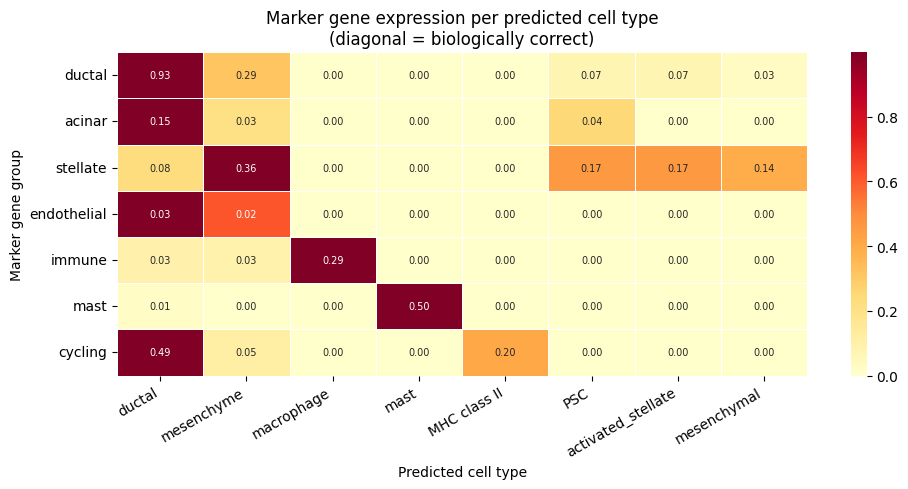

Saved → outputs/marker_gene_heatmap.png


In [15]:
# mean expression of each marker gene group, split by predicted cell type
cells_with_pred = cells.copy()
cells_with_pred["predicted_cell_type"] = predictions["predicted_cell_type"]

rows = []
for marker_type, genes in available_markers.items():
    mean_expr = cells_with_pred.groupby("predicted_cell_type")[genes].mean().mean(axis=1)
    mean_expr.name = marker_type
    rows.append(mean_expr)

marker_df = pd.DataFrame(rows)  # marker_type × predicted_cell_type

# normalise each row so colours reflect relative enrichment, not absolute counts
marker_df_norm = marker_df.div(marker_df.max(axis=1) + 1e-9, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))

# define the mapping: which column should each row peak in
row_to_col = {
    "ductal":      "ductal",
    "acinar":      "ductal",       # acinar peaks in ductal — may reflect shared markers
    "stellate":    "mesenchyme",
    "endothelial": "mesenchyme",   # weak signal, nearest peak
    "immune":      "macrophage",
    "mast":        "mast",
    "cycling":     "MHC class II",
}

# reorder columns to follow the row sequence
col_order = []
for row in marker_df_norm.index:
    target = row_to_col.get(row)
    if target and target in marker_df_norm.columns and target not in col_order:
        col_order.append(target)
# append any remaining columns
col_order += [c for c in marker_df_norm.columns if c not in col_order]

marker_df_norm = marker_df_norm[col_order]
marker_df = marker_df[col_order]

sns.heatmap(
    marker_df_norm,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.4,
    annot=marker_df.round(2),
    fmt=".2f",
    annot_kws={"size": 7}
)
ax.set_title("Marker gene expression per predicted cell type\n(diagonal = biologically correct)")
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("Marker gene group")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/marker_gene_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → outputs/marker_gene_heatmap.png")

## 3 · Confidence scoring

A low best-similarity score means the cell doesn't strongly resemble *any* prototype —
either it's a rare/unknown cell type, or the segmentation boundary was wrong and the
transcript counts are polluted by a neighbour.

In [6]:
predictions["confidence"] = predictions["best_similarity"]
predictions["low_confidence"] = predictions["confidence"] < CONFIDENCE_THRESHOLD

n_low = predictions["low_confidence"].sum()
n_total = len(predictions)
print(f"Low-confidence cells (score < {CONFIDENCE_THRESHOLD}): {n_low} / {n_total} ({100*n_low/n_total:.1f}%)")
print()
print("Low-confidence breakdown by predicted type:")
print(predictions[predictions["low_confidence"]]["predicted_cell_type"].value_counts())

Low-confidence cells (score < 0.5): 75 / 81 (92.6%)

Low-confidence breakdown by predicted type:
predicted_cell_type
ductal                46
PSC                    9
mesenchyme             9
mesenchymal            4
activated_stellate     3
MHC class II           2
mast                   1
macrophage             1
Name: count, dtype: int64


Low-confidence by margin (< 0.05): 25 / 81


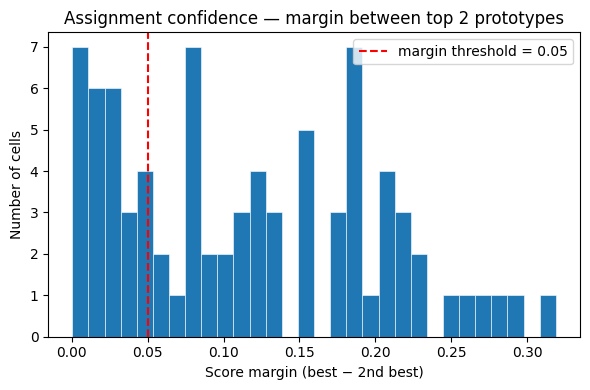

In [7]:
# margin = gap between best and second-best prototype score
sorted_scores = np.sort(sim_df.values, axis=1)
margin = sorted_scores[:, -1] - sorted_scores[:, -2]

predictions["margin"] = margin
predictions["low_confidence"] = predictions["margin"] < MARGIN_THRESHOLD

print(f"Low-confidence by margin (< {MARGIN_THRESHOLD}): {predictions['low_confidence'].sum()} / {len(predictions)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(predictions["margin"], bins=30, edgecolor="white", linewidth=0.4)
ax.axvline(MARGIN_THRESHOLD, color="red", linestyle="--", label=f"margin threshold = {MARGIN_THRESHOLD}")
ax.set_xlabel("Score margin (best − 2nd best)")
ax.set_ylabel("Number of cells")
ax.set_title("Assignment confidence — margin between top 2 prototypes")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/margin_histogram.png", dpi=300)
plt.show()

## 4 · Spatial confidence map

Colour each segmented cell by its similarity score to see whether low-confidence cells
cluster in specific tissue regions (e.g. boundaries, sparse areas).

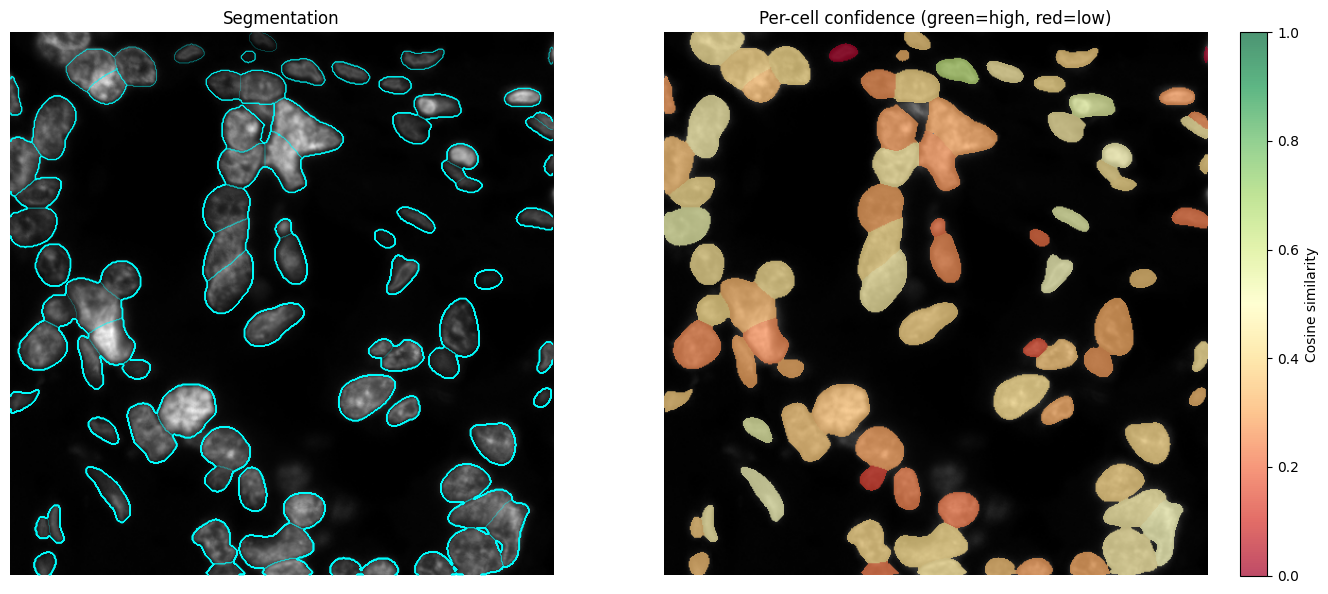

Saved → outputs/confidence_map.png


In [8]:
with tiff.TiffFile(IMAGE_PATH) as tif:
    img = tif.pages[0].asarray()
if img.ndim == 3:
    img = img[..., 0]
h, w = img.shape
start_y = h // 2 - CROP_SIZE // 2
start_x = w // 2 - CROP_SIZE // 2
img_crop = img[start_y:start_y + CROP_SIZE, start_x:start_x + CROP_SIZE].astype(float)
img_crop = (img_crop - img_crop.min()) / (img_crop.max() - img_crop.min() + 1e-8)

# build a per-pixel confidence map from the mask
confidence_map = np.zeros(masks.shape, dtype=float)
for cell_id_str, row in predictions.iterrows():
    # cell IDs in predictions index may be strings like 'cell_1' or ints
    try:
        cell_id = int(str(cell_id_str).replace("cell_", ""))
    except ValueError:
        continue
    confidence_map[masks == cell_id] = row["confidence"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: raw image with cell outlines
axes[0].imshow(img_crop, cmap="gray")
levels = np.unique(masks)[1:]
if len(levels):
    axes[0].contour(masks, levels=levels, linewidths=0.3, colors="cyan", alpha=0.5)
axes[0].set_title("Segmentation")
axes[0].axis("off")

# right: confidence heatmap
axes[1].imshow(img_crop, cmap="gray")
conf_masked = np.ma.masked_where(masks == 0, confidence_map)
im = axes[1].imshow(conf_masked, cmap="RdYlGn", vmin=0, vmax=1, alpha=0.7)
plt.colorbar(im, ax=axes[1], fraction=0.046, label="Cosine similarity")
axes[1].set_title("Per-cell confidence (green=high, red=low)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confidence_map.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → outputs/confidence_map.png")

## 5 · Post-processing: re-segment low-confidence cells

For each low-confidence cell, we crop a small patch around it and re-run Cellpose
at a different diameter. If the new segmentation produces a cell whose cosine score
exceeds the threshold, we accept it; otherwise we keep the original assignment but
leave the `low_confidence` flag set.

This is the biological integration step: morphology-only segmentation is used first,
then gene expression is used to decide whether to trust or retry each cell boundary.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

flagged = predictions[predictions["low_confidence"]].copy()
print(f"Re-segmenting {len(flagged)} low-confidence cells at diameter={RETRY_DIAMETER}...")

model = models.CellposeModel(gpu=True)
proto_values = prototypes.values  # (n_types, n_genes)
shared_genes = list(prototypes.columns)

improved = 0
patch_size = 80  # pixels around each cell centre to crop for retry

refined_predictions = predictions.copy()

for cell_id_str in flagged.index:
    try:
        cell_id = int(str(cell_id_str).replace("cell_", ""))
    except ValueError:
        continue

    # find cell centre from mask
    ys, xs = np.where(masks == cell_id)
    if len(ys) == 0:
        continue
    cy, cx = int(ys.mean()), int(xs.mean())

    # crop patch around the cell
    y0 = max(0, cy - patch_size // 2)
    y1 = min(CROP_SIZE, cy + patch_size // 2)
    x0 = max(0, cx - patch_size // 2)
    x1 = min(CROP_SIZE, cx + patch_size // 2)
    patch = img_crop[y0:y1, x0:x1]

    if patch.size == 0:
        continue

    # re-run cellpose on the patch
    patch_masks, _, _ = model.eval(patch, diameter=RETRY_DIAMETER, batch_size=1)

    # find the central cell in the new patch mask
    patch_cy = (y1 - y0) // 2
    patch_cx = (x1 - x0) // 2
    new_cell_id = patch_masks[patch_cy, patch_cx]
    if new_cell_id == 0:
        continue  # no cell found at centre — keep original

    # count transcripts in the new mask region
    # (reuse assigned transcripts from the full crop — filter by patch region)
    # NOTE: this requires assigned_transcripts_crop.csv to have x_local, y_local columns
    try:
        assigned = pd.read_csv("../data/assigned_transcripts_crop.csv")
        patch_tx = assigned[
            (assigned["x_local"] >= x0) & (assigned["x_local"] < x1) &
            (assigned["y_local"] >= y0) & (assigned["y_local"] < y1)
        ].copy()
        patch_tx["patch_cell"] = patch_masks[
            (patch_tx["y_local"] - y0).astype(int).clip(0, patch_masks.shape[0]-1),
            (patch_tx["x_local"] - x0).astype(int).clip(0, patch_masks.shape[1]-1)
        ]
        cell_tx = patch_tx[patch_tx["patch_cell"] == new_cell_id]
        gene_col = "feature_name" if "feature_name" in cell_tx.columns else "gene_name"
        new_expr = cell_tx[gene_col].value_counts().reindex(shared_genes, fill_value=0).values.reshape(1, -1)
    except Exception:
        continue

    # compute cosine similarity with all prototypes
    new_expr_norm = normalize(new_expr, norm="l2")
    if new_expr_norm.sum() == 0:
        continue
    scores = cos_sim(new_expr_norm, proto_values)[0]
    best_score = scores.max()
    best_type = prototypes.index[scores.argmax()]

    if best_score > predictions.loc[cell_id_str, "best_similarity"]:
        refined_predictions.loc[cell_id_str, "predicted_cell_type"] = best_type
        refined_predictions.loc[cell_id_str, "best_similarity"] = best_score
        refined_predictions.loc[cell_id_str, "confidence"] = best_score
        refined_predictions.loc[cell_id_str, "low_confidence"] = best_score < CONFIDENCE_THRESHOLD
        improved += 1

print(f"Improved: {improved} / {len(flagged)} low-confidence cells")
refined_predictions.to_csv(REFINED_PATH)
print(f"Saved refined predictions → {REFINED_PATH}")

Re-segmenting 25 low-confidence cells at diameter=20...


/Users/mehdi/Desktop/Computational Genomics Project/venv/lib/python3.13/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


Improved: 6 / 25 low-confidence cells
Saved refined predictions → ../data/cell_type_predictions_refined.csv


## 6 · Before / after comparison

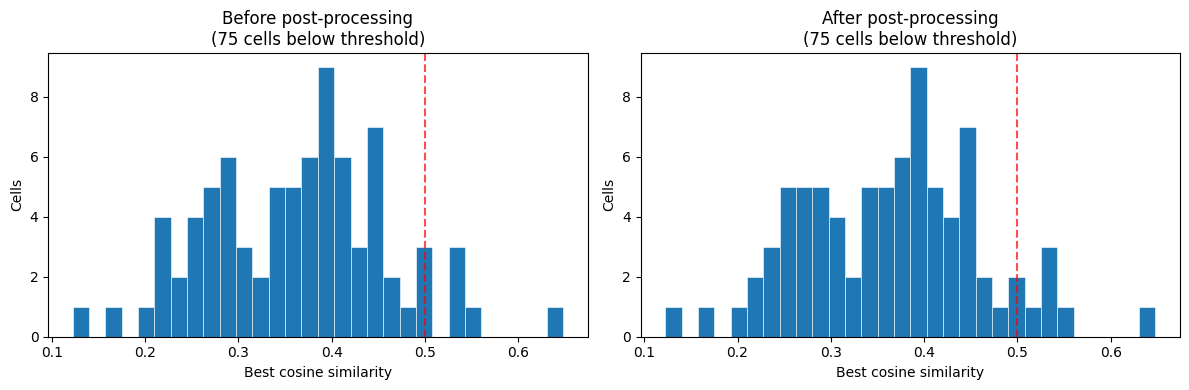

In [10]:
# reload original predictions for the "before" snapshot
predictions_original = pd.read_csv(PREDICTIONS_PATH, index_col=0)
predictions_refined  = pd.read_csv(REFINED_PATH, index_col=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(
    axes,
    [predictions_original, predictions_refined],
    ["Before post-processing", "After post-processing"]
):
    ax.hist(df["best_similarity"], bins=30, edgecolor="white", linewidth=0.4)
    ax.axvline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", alpha=0.7)
    n_low = (df["best_similarity"] < CONFIDENCE_THRESHOLD).sum()
    ax.set_title(f"{title}\n({n_low} cells below threshold)")
    ax.set_xlabel("Best cosine similarity")
    ax.set_ylabel("Cells")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/before_after_postprocessing.png", dpi=300)
plt.show()

## 7 · Flagged cells overlay

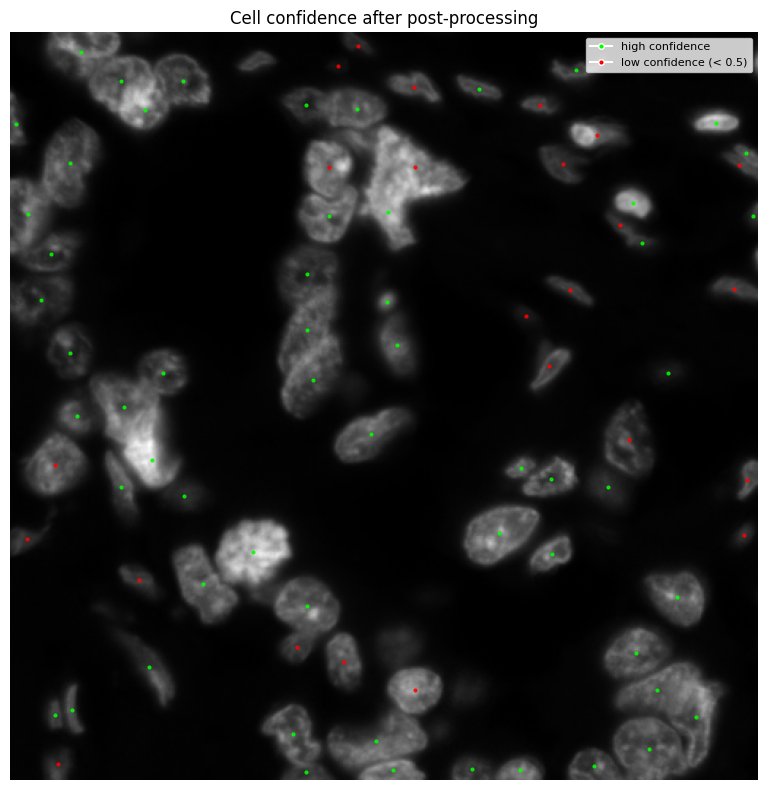

Saved → outputs/flagged_cells_overlay.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_crop, cmap="gray")

for cell_id_str, row in refined_predictions.iterrows():
    try:
        cell_id = int(str(cell_id_str).replace("cell_", ""))
    except ValueError:
        continue
    color = "red" if row["low_confidence"] else "lime"
    ys, xs = np.where(masks == cell_id)
    if len(ys):
        ax.plot(xs.mean(), ys.mean(), ".", color=color, markersize=4, alpha=0.8)

# legend
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker=".", color="w", markerfacecolor="lime", markersize=8, label="high confidence"),
    Line2D([0],[0], marker=".", color="w", markerfacecolor="red",  markersize=8, label=f"low confidence (< {CONFIDENCE_THRESHOLD})"),
], loc="upper right", fontsize=8)

ax.set_title("Cell confidence after post-processing")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/flagged_cells_overlay.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → outputs/flagged_cells_overlay.png")